In this NB we will try to analyse the discounts based on the cleaned data set.
We obtained the final csv files after cleaning all duplicates, wrong values, NaN values and not matching values.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# # orders.csv
orders = pd.read_csv('../data/orders_ext_rev2.csv')

# # orderlines.csv
orderlines = pd.read_csv('../data/orderlines_ext_rev2.csv')

# # products.csv
products = pd.read_csv('../data/products_cat_rev2.csv')

# # brands.csv
brands = pd.read_csv('../data/cleaned_brands_file.csv')

In [3]:
# let's sellect only the columns (we think) we need 
orderlines_df = orderlines.loc[ : , ["date", "id_order","sku","unit_price"]]
# and convert the date format
orderlines_df["date"] = pd.to_datetime(orderlines_df["date"])
# let's sellect the columns from products as well 
#products_df = products.loc[ :, ['price', 'sku', 'name']] 
# if you have crated col 'state' for the condition (new, used, refurbished) use the line below
products_df = products.loc[ :, ['price', 'sku', 'name', 'brand', 'state', 'type', 'category', 'type_cat', 'primary', 'secondary']] 

In [4]:
# Here we dont need actually so namy states 
# products_df.loc[products_df["state"].str.contains("open ", regex=False, case=False), "state"] = "second hand"
# products_df.loc[products_df["state"].str.contains("excellent", case=False), "state"] = "second hand"
# products_df.loc[products_df["state"].str.contains("like new", case=False), "state"] = "second hand"
# products_df.loc[products_df["state"].str.contains("second hand", case=False), "state"] = "second hand"
# products_df.loc[products_df["state"].str.contains("repair", case=False), "state"] = "repair"
products_df.loc[products_df["state"].str.contains("open", regex=False, case=False), "state"] = "second hand"
products_df.loc[products_df["state"].str.contains("excellent", case=False), "state"] = "second hand"
products_df.loc[products_df["state"].str.contains("like new", case=False), "state"] = "second hand"
products_df.loc[products_df["state"].str.contains("second hand", case=False), "state"] = "second hand"
products_df.loc[products_df["state"].str.contains("repair", case=False), "state"] = "repair"

In [7]:
# as next we merge both df
discount=orderlines_df.merge(products_df, how='left', on='sku')
# we set up a disc column
discount.loc[:,"disc"] = discount["price"]- discount["unit_price"]
# and calculate the discount as precentage
discount.loc[:, "percent"] = (100*discount["disc"]/discount["price"]).round(2)
# and play with time
discount.loc[:,"year"] = discount["date"].dt.year
discount.loc[:,"month"] = discount["date"].dt.month
discount.loc[:,"day"] = discount["date"].dt.day
discount.loc[:,"weekday"] = discount["date"].dt.day_name()
discount_df = discount.set_index('date').copy()
#discount_df

In [ ]:
# # you need to have col 'state' for this and probably do some changes in the code above
# discount_df.groupby(['state'])['percent'].mean()

# # Calculates the mean percent per state and plots it
# avg_discount = discount_df.groupby('state')['percent'].mean().reset_index()

# sns.barplot(data=avg_discount, x='state', y='percent')
# plt.show()

# # Creates a boxplot showing the distribution for each state
# sns.boxplot(data=discount_df, x='state', y='percent')

# #plt.savefig('../MyEniacProject/Presentation/figs/box_disc_state.svg')
# plt.show()

# # Calculate means across a secondary group (e.g., month/date)
# state_means = discount_df.groupby(['state', 'date'])['percent'].mean().reset_index()

# # Plot the distribution of those averages per state
# sns.violinplot(data=state_means, x='state', y='percent')
# plt.show()


state
new            20.652324
repair         17.379540
second hand    30.489070
Name: percent, dtype: float64

In [ ]:
# Next we make a new df with daily % of discount, revenue and number of items sold
disc_rev_items_df = (discount.resample('D', on='date')
          .agg({'percent': 'mean', 
                'unit_price': 'sum', 
                'sku': 'count'})  # or any column for count
          .rename(columns={'unit_price': 'revenue', 'sku': 'items', 'percent' : 'perc_disc'})
          ) 


# # Next we make a new df with daily % of discount, revenue and number of items sold
# disc_rev_items_df = (discount.resample('ME', on='date')  # we can play with sampling frequency W; ME; D
#           .agg({'percent': 'mean', 
#                 'unit_price': 'sum', 
#                 'sku': 'count'})  # or any column for count
#           .rename(columns={'unit_price': 'revenue', 'sku': 'items', 'percent' : 'perc_disc'}))


# just to be sure we reset the index
#disc_rev_items_df.reset_index().copy





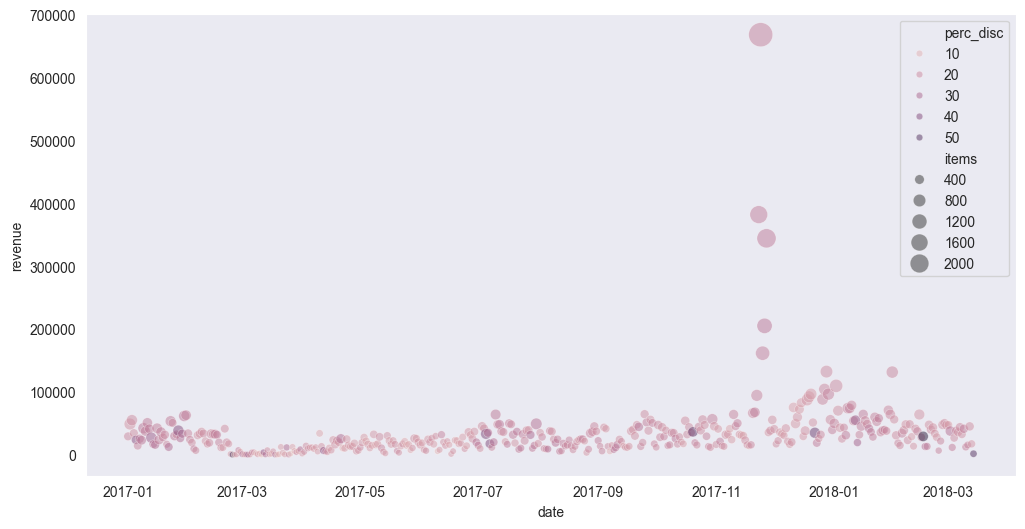

In [7]:
# The same data as below, just as time line to get idea about outliers
sns.set_style("dark")

# Line chart 
plt.figure(figsize=(12,6))
sns.scatterplot(data=disc_rev_items_df, 
                x='date', 
                y='revenue',     
                hue='perc_disc',
                size='items',
                sizes=(20, 300),
                alpha=0.5, # transperancy
                )
plt.legend(markerscale=0.8) # reduce the size of the dots in the legend
# once you are ready with the figure, you can seve it in the proper folder
#plt.savefig('../MyEniacProject/Presentation/figs/daily_rev_perc_disc_items.svg')
sns.set_theme(context='paper', style='dark')

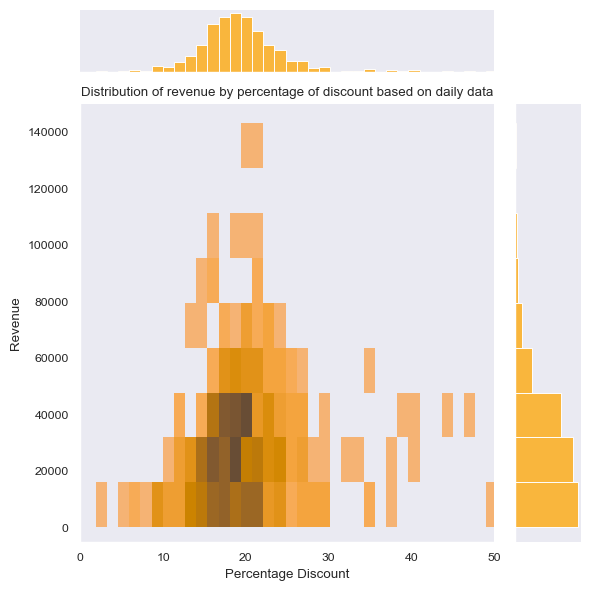

In [8]:
# we can use different kinds, i like kde, but it gives misliding negative values ...
#discount_df.unit_price.sort_values() #ise to check if we really have negative values :)
# This plot is connected to the code above, so if you change the sampling frequency, your plot will be affected!

g = sns.jointplot(      # small adjusment to make custom labeling possible
    data=disc_rev_items_df, 
    x='perc_disc', 
    y='revenue', 
    #hue ='items',
    kind="hist",
    palette="vlag",
    color='orange',
)

# Set title on the joint axes
g.ax_joint.set_title("Distribution of revenue by percentage of discount based on daily data")

# Fix axis labels
g.ax_joint.set_xlabel("Percentage Discount")
g.ax_joint.set_ylabel("Revenue")

# Set axis limits on the joint axes
g.ax_joint.set_xlim(0, 50)
g.ax_joint.set_ylim(-5000, 150000)
# once you are ready with the figure, you can seve it in the proper folder
#plt.savefig('../MyEniacProject/Presentation/figs/distr_rev_perc_disc.svg')
plt.tight_layout()
plt.show()

In [9]:
#Again the same data but as interactive plotly....

import plotly.express as px
import plotly.io as pio

fig = px.scatter(disc_rev_items_df, y='revenue', 
                 color='items', size='perc_disc', 
                 range_color=[0, 500],# hue -> color, size stays
                 size_max=40, 
                 log_y= True,
                 title='Daily Revenue by Items and Discount')
fig.update_layout(width=800, height=500, 
                  plot_bgcolor='black', paper_bgcolor='black',
                  font_color='white')  # Dark theme like seaborn
#fig.write_html('plot.html')
pio.write_html(fig, file="plot2.html", full_html=True, include_plotlyjs='cdn')
#fig.write_html("fig_test2.html", include_plotlyjs='cdn')
fig.show()

In [10]:
# new df with the daily avg discount and reveneu 

daily_avg_disc_by_state = (
    discount_df
    .groupby([discount_df.index.date, 'state'])['disc'] # sampling frequency chan be changed here
    .mean()
    .reset_index()
    .rename(columns={'index': 'date', 'disc': 'avg_disc'})
)
#daily_avg_disc_by_state =daily_avg_disc_by_state.reset_index().copy()

#sns.scatterplot(data=daily_avg_disc_by_state)

#average discount by state across the full dataset
# pie_df = (
#     discount_df
#     .groupby('state')['disc']
#     .mean()
#     .sort_values(ascending=False)
# )

# plt.figure(figsize=(8, 8))
# plt.pie(
#     pie_df,
#     labels=pie_df.index,
#     autopct='%1.1f%%',
#     startangle=90
# )
# plt.title('Average Discount by State')
# plt.axis('equal')
# plt.show()

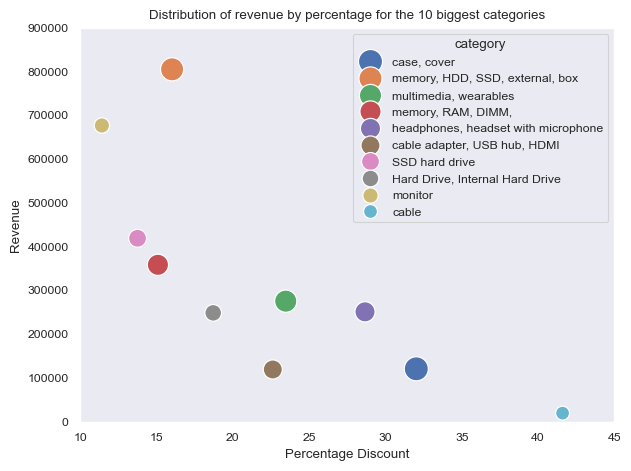

In [11]:
# let's try to make someting else
# discount_df.groupby('type').agg(
#     avg_percent=('percent', 'mean'),
#     total_unit_price=('unit_price', 'sum')
# ) 
#OK we need some improvment
# 
# # we take the first 10 types (by number of orders) an look on  
by_type_df  = discount_df.groupby('type').agg(
    avg_percent=('percent', 'mean'),    # avg disc per type
    revenue=('unit_price', 'sum'),      # total revenue per type
    count=('type', 'count'),            # sells by type
    category=('type_cat', 'first')      # cathegory by type, we need it for labling 
).nlargest(10, 'count')

# as next we make the plot:
fig, ax = plt.subplots()
sns.scatterplot(data=by_type_df, 
                x='avg_percent', 
                y='revenue', 
                hue='category', 
                size='category',
                sizes=(100, 300),
                ax=ax)

ax.set_title("Distribution of revenue by percentage for the 10 biggest categories")

# Fix axis labels
ax.set_xlabel("Percentage Discount")
ax.set_ylabel("Revenue")

# Set axis limits on the joint axes
ax.set_xlim(10, 45)
ax.set_ylim(0,  900000)
plt.tight_layout()

# once you are ready with the figure, you can seve it in the proper folder
#plt.savefig('../MyEniacProject/Presentation/figs/distr_rev_perc_disc_top10.svg')

#If we want to lable the points in the figure
# for idx, row in by_type_df.iterrows():
#     plt.text(row['avg_percent'], row['revenue'],  fontsize=9)

# plt.xlim(0, 50)   # limit x-axis
# plt.ylim(-15000, 150000)    # limit y-axis

In [12]:
# # # we take the first 10 types (by number of orders) an look on  
# by_type_df  = discount_df.groupby('type').agg(
#     avg_percent=('percent', 'mean'),    # avg disc per type
#     revenue=('unit_price', 'sum'),      # total revenue per type
#     count=('type', 'count'),            # sells by type
#     category=('type_cat', 'first')      # cathegory by type, we need it for labling 
# ).nlargest(10, 'count')
# fig, ax = plt.subplots()
# sns.scatterplot(data=by_type_df, x='avg_percent', y='revenue', hue='category', ax=ax)


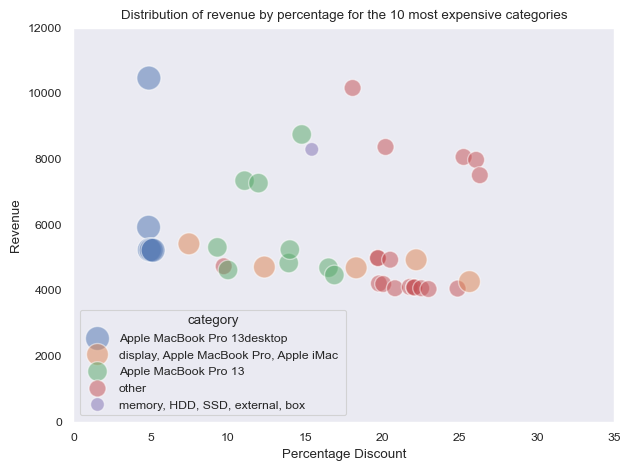

In [13]:
top10_expensive = discount_df.groupby('sku')['price'].max().nlargest(20).index

df_expensive = discount_df[discount_df['sku'].isin(top10_expensive)]

result_expensive = df_expensive.groupby('percent').agg(
    sales=('id_order', 'count'),
    avg_discount=('percent', 'mean'),
    total_revenue=('unit_price', 'sum'),
    total_cost=('price', 'sum'),
    category=('type_cat', 'first')
).reset_index()

fig, ax = plt.subplots()
sns.scatterplot(data=result_expensive, 
                x='avg_discount', 
                y='total_revenue',
                hue='category', 
                size='category',
                sizes=(100, 300),
                alpha = 0.5,
                ax=ax)

ax.set_title("Distribution of revenue by percentage for the 10 most expensive categories")

# Fix axis labels
ax.set_xlabel("Percentage Discount")
ax.set_ylabel("Revenue")

# Set axis limits on the joint axes
ax.set_xlim(0, 35)
ax.set_ylim(0, 12000)
plt.tight_layout()

# once you are ready with the figure, you can seve it in the proper folder
plt.savefig('../MyEniacProject/Presentation/figs/distr_rev_perc_disc_top10exp.svg')

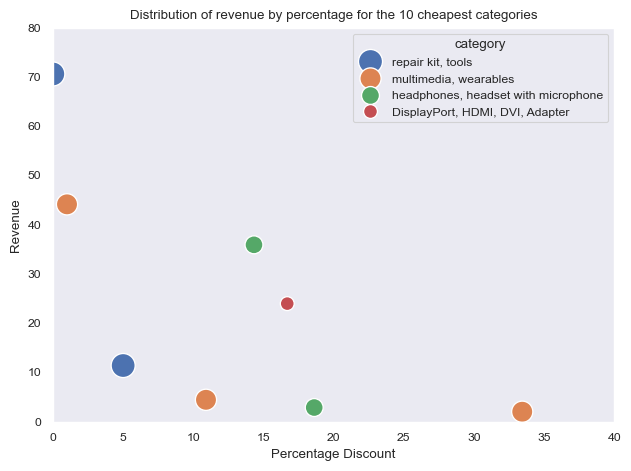

In [14]:
top10_cheap = discount_df.groupby('sku')['price'].min().nsmallest(10).index

df_cheap = discount_df[discount_df['sku'].isin(top10_cheap )]

result_cheap= df_cheap.groupby('percent').agg(
    sales=('id_order', 'count'),
    avg_discount=('percent', 'mean'),
    total_revenue=('unit_price', 'sum'),
    total_cost=('price', 'sum'),
    category=('type_cat', 'first')
).reset_index()
fig, ax = plt.subplots()

sns.scatterplot(data=result_cheap, 
                x='avg_discount', 
                y='total_revenue', 
                hue='category', 
                size='category',
                sizes=(100, 300),
                ax=ax)

ax.set_title("Distribution of revenue by percentage for the 10 cheapest categories")

# Fix axis labels
ax.set_xlabel("Percentage Discount")
ax.set_ylabel("Revenue")

# Set axis limits on the joint axes
ax.set_xlim(0, 40)
ax.set_ylim(0, 80)
plt.tight_layout()

# once you are ready with the figure, you can seve it in the proper folder
#plt.savefig('../MyEniacProject/Presentation/figs/distr_rev_perc_disc_top10cheap.svg')

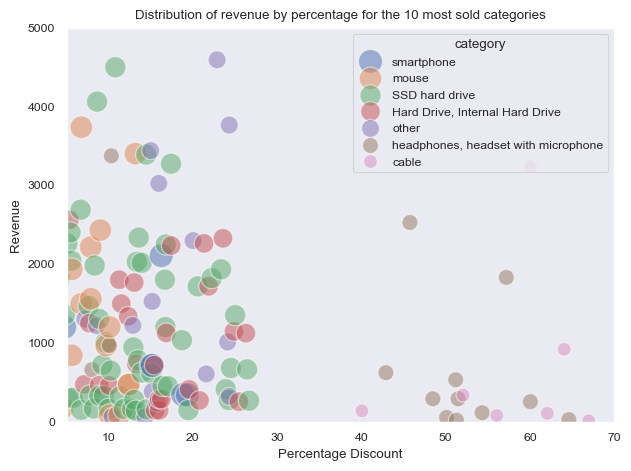

In [15]:
# we do the same for the 10 most sold 
#discount_df = discount_df[discount_df['state'] == 'new']  # not sure why we have many outliers, to be sure i tried to 
top10_most_sold = discount_df.groupby('sku')['id_order'].count().nlargest(10).index # we group by sku, count by id_order and take the first 10
# make a mask and use it to filter
df_most_sold = discount_df[discount_df['sku'].isin(top10_most_sold)]

result_most_sold = df_most_sold.groupby('percent').agg(
    sales=('id_order', 'count'),
    avg_discount=('percent', 'mean'),
    total_revenue=('unit_price', 'sum'),
    total_cost=('price', 'sum'),
    category=('type_cat', 'first')
).reset_index()

fig, ax = plt.subplots()
sns.scatterplot(data=result_most_sold, 
                x='avg_discount', 
                y='total_revenue', 
                hue='category', 
                size='category',
                sizes=(100, 300),
                alpha=0.5,
                ax=ax)

ax.set_title("Distribution of revenue by percentage for the 10 most sold categories")

# Fix axis labels
ax.set_xlabel("Percentage Discount")
ax.set_ylabel("Revenue")

# Set axis limits on the joint axes
ax.set_xlim(5, 70)
ax.set_ylim(0, 5000)
plt.tight_layout()

# once you are ready with the figure, you can seve it in the proper folder
#plt.savefig('../MyEniacProject/Presentation/figs/distr_rev_perc_disc_top10sells.svg')

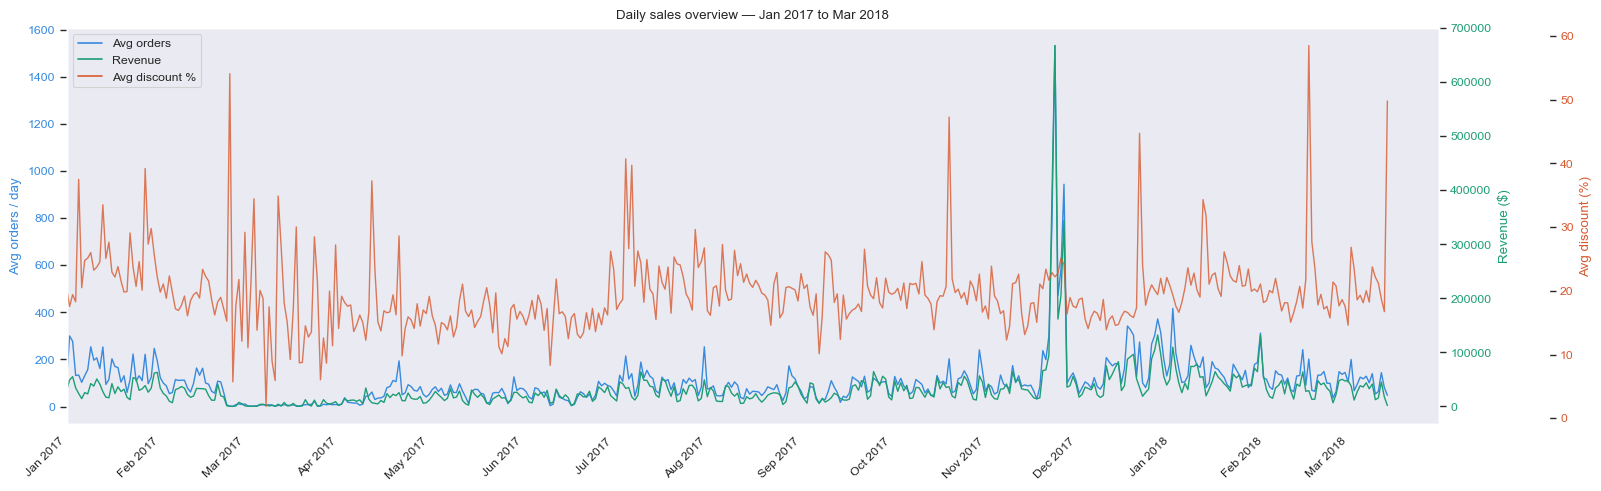

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# make sure date is datetime
discount["date"] = pd.to_datetime(discount["date"])

# daily aggregation
daily = discount.groupby(discount["date"].dt.date).agg(
    avg_orders=("id_order", "nunique"),
    revenue=("unit_price", "sum"),
    avg_discount_pct=("percent", "mean")
).reset_index()

daily["date"] = pd.to_datetime(daily["date"])

# plot
fig, ax1 = plt.subplots(figsize=(16, 5))

# axis 2 and 3
ax2 = ax1.twinx()
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("axes", 1.08))  # push 3rd axis outward

# 1) avg orders
ax1.plot(daily["date"], daily["avg_orders"], color="#378ADD", linewidth=1, label="Avg orders")
ax1.set_ylabel("Avg orders / day", color="#378ADD")
ax1.tick_params(axis="y", labelcolor="#378ADD")

# 2) revenue
ax2.plot(daily["date"], daily["revenue"], color="#1D9E75", linewidth=1, label="Revenue")
ax2.set_ylabel("Revenue ($)", color="#1D9E75")
ax2.tick_params(axis="y", labelcolor="#1D9E75")

# 3) avg discount %
ax3.plot(daily["date"], daily["avg_discount_pct"], color="#D85A30", linewidth=1, alpha=0.8, label="Avg discount %")
ax3.set_ylabel("Avg discount (%)", color="#D85A30")
ax3.tick_params(axis="y", labelcolor="#D85A30")

# x axis formatting
ax1.set_xlim(pd.Timestamp("2017-01-01"), pd.Timestamp("2018-03-31"))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")

# legend
lines = [
    plt.Line2D([0],[0], color="#378ADD", label="Avg orders"),
    plt.Line2D([0],[0], color="#1D9E75", label="Revenue"),
    plt.Line2D([0],[0], color="#D85A30", label="Avg discount %"),
]
ax1.legend(handles=lines, loc="upper left")

plt.title("Daily sales overview — Jan 2017 to Mar 2018")
plt.tight_layout()

#once you are ready with the figure, you can seve it in the proper folder
#plt.savefig('../MyEniacProject/Presentation/figs/daily_sales_overviews.svg')
plt.show()

## 1. Distribution of sales by price

<Axes: xlabel='unit_price', ylabel='Count'>

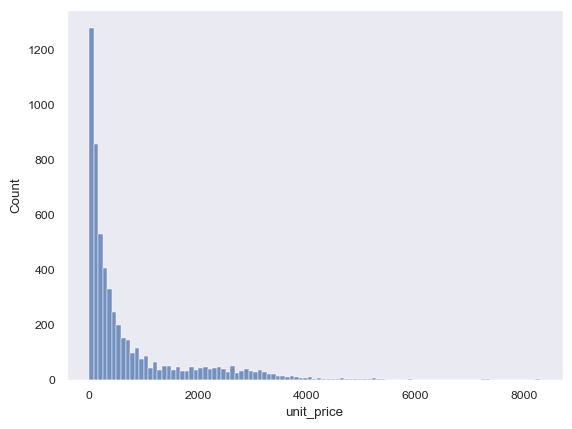

In [17]:
price_counts_df= discount.groupby("unit_price").agg(
    sales_count=("id_order", "count"),
    revenue=("unit_price", "sum")
).sort_values("unit_price", ascending=False)

#price_counts_df.info()

sns.histplot(data=price_counts_df, x='unit_price', log_scale=(False, False))


# once you are ready with the figure, you can seve it in the proper folder
#plt.savefig('../MyEniacProject/Presentation/figs/distr_rev_perc_disc_top10sells.svg')

In [ ]:
# fig, ax = plt.subplots(figsize=(12, 5))
# sns.histplot(data=discount_df[discount_df['unit_price'] > 0],
#              x='unit_price',
#              log_scale=(True, False),
#              ax=ax, label='unit_price', color='blue', alpha=0.4)

# sns.histplot(data=discount_df[discount_df['price'] > 0],
#              x='price',
#              log_scale=(True, False),
#              ax=ax, label='price', color='orange', alpha=0.4)

# ax.legend(['reduced price', 'regular price'])
# ax.set_xlabel("Unit Price")
# ax.set_ylabel("Count")

# # Set axis limits on the joint axes
# ax.set_xlim(1, 10000)
# ax.set_ylim(0, 3000)
# plt.tight_layout()

In [19]:
# df_melted = discount_df[['unit_price', 'price']].melt(var_name='type', value_name='value')
# df_melted = df_melted[df_melted['value'] > 0]

# fig, ax = plt.subplots(figsize=(12, 5))
# sns.histplot(data=df_melted, x='value', hue='type',
#              log_scale=(True, False),
#              multiple='fill', # 'stack' -  stacks the bars on top of each other,'layer' — overlapping, 'dodge' — side by side ,'fill' — stacked and normalized to 1 (shows proportions)
#              ax=ax)
# ax.set_xlabel("Unit Price")
# ax.set_ylabel("Count")

# # Set axis limits on the joint axes
# ax.set_xlim(1, 10000)
# ax.set_ylim(0, 1)
# plt.tight_layout()

In [20]:
# sku_df = discount_df[discount_df['price'] > 0].groupby('sku').agg(
#     mean_unit_price=('unit_price', 'mean'),
#     price=('price', 'first')  # or 'mean' if price varies per SKU
# ).reset_index()

# fig, ax = plt.subplots(figsize=(12, 5))

# ax.scatter(
#     sku_df['price'],
#     sku_df['mean_unit_price'],
#     alpha=0.4, color='blue', label='Mean Unit Price per SKU'
# )

# ax.set_xscale('log')
# ax.set_xlabel("Price")
# ax.set_ylabel("Mean Unit Price")
# ax.set_xlim(1, 10000)
# ax.legend()
# plt.tight_layout()
# plt.show()

In [21]:
# import numpy as np

# bin_size = 25  # or 10

# # Create price bins
# bins = np.arange(0, discount_df['price'].max() + bin_size, bin_size)

# # Assign each row to a bin
# discount_df['price_bin'] = pd.cut(discount_df['price'], bins=bins)

# # Group by bin and compute mean unit_price
# binned = discount_df.groupby('price_bin', observed=True)['unit_price'].mean().reset_index()
# binned['bin_left'] = binned['price_bin'].apply(lambda x: x.left)

# fig, ax = plt.subplots(figsize=(12, 5))

# ax.bar(
#     binned['bin_left'],
#     binned['unit_price'],
#     width=bin_size * 0.9,
#     color='blue', alpha=0.6, label='Mean reduced price per bin'
# )

# ax.set_xlabel("Regular Price (€)")
# ax.set_ylabel("Mean Reduced Price (€)")
# #ax.set_xlim(0, 10000)
# ax.set_xscale('log')
# ax.legend()
# plt.tight_layout()
# plt.show()

In [22]:
print((discount_df['unit_price'] <= 0).sum())

0


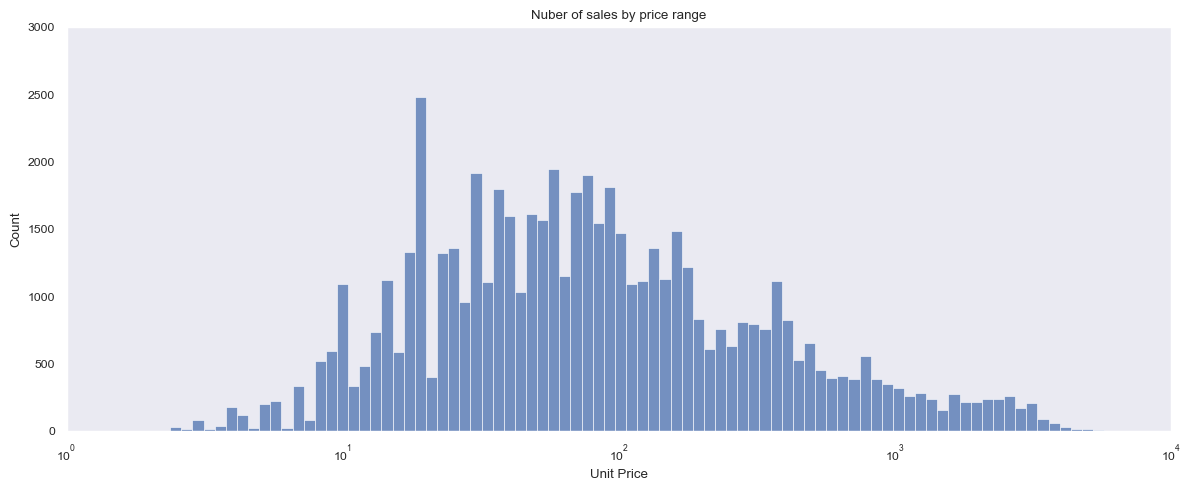

In [23]:
pythonfig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(data=discount_df, 
             x='unit_price', 
             log_scale=(True ,False),
             ax=ax)
# Fix axis labels
plt.title("Nuber of sales by price range")
ax.set_xlabel("Unit Price")
ax.set_ylabel("Count")

# Set axis limits on the joint axes
ax.set_xlim(1, 10000)
ax.set_ylim(0, 3000)
plt.tight_layout()

# once you are ready with the figure, you can seve it in the proper folder
#plt.savefig('../MyEniacProject/Presentation/figs/distr_salles_price.svg')

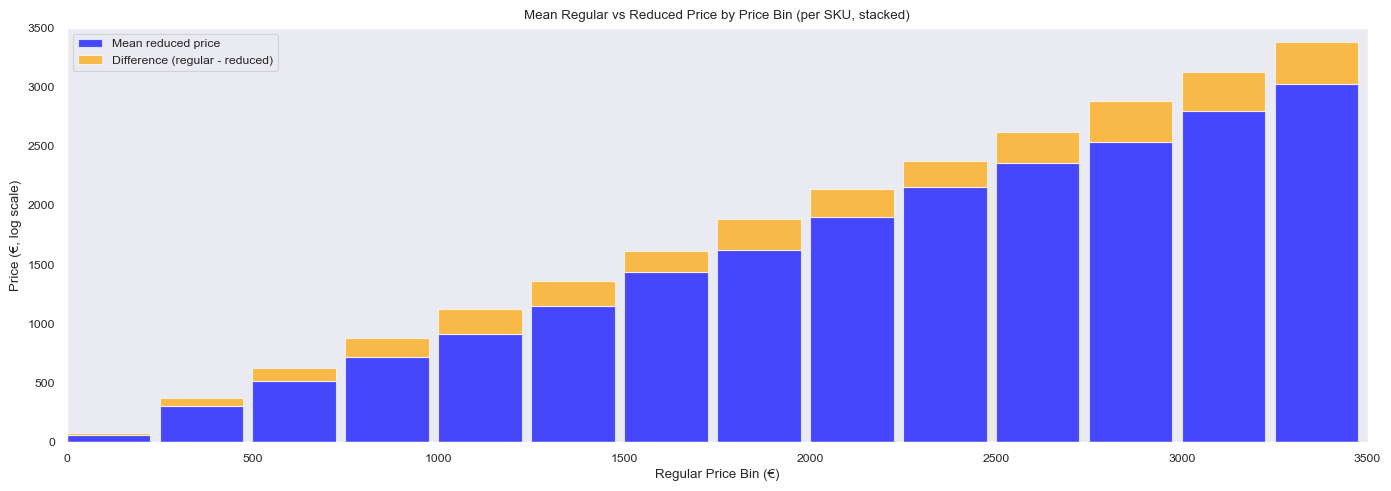

In [24]:
import numpy as np
import matplotlib.pyplot as plt

bin_size = 250

# Step 1: Aggregate by SKU first
sku_df = discount_df.groupby('sku').agg(
    mean_price=('price', 'mean'),
    mean_unit_price=('unit_price', 'mean')
).reset_index()

# Step 2: Bin by mean price
bins = np.arange(0, sku_df['mean_price'].max() + bin_size, bin_size)
sku_df['price_bin'] = pd.cut(sku_df['mean_price'], bins=bins)

# Step 3: Single groupby
binned = sku_df.groupby('price_bin', observed=True).agg(
    mean_price=('mean_price', 'mean'),
    mean_unit_price=('mean_unit_price', 'mean'),
    sku_count=('sku', 'count')
).reset_index()
binned['bin_left'] = binned['price_bin'].apply(lambda x: x.left).astype(float)

# Step 4: Plot stacked bars with log y-axis
fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(binned['bin_left'], binned['mean_unit_price'],
       width=bin_size * 0.9, align='edge',
       color='blue', alpha=0.7, label='Mean reduced price')

ax.bar(binned['bin_left'], binned['mean_price'] - binned['mean_unit_price'],
       width=bin_size * 0.9, align='edge',
       bottom=binned['mean_unit_price'],
       color='orange', alpha=0.7, label='Difference (regular - reduced)')

#ax.set_yscale('log')
ax.set_xlabel("Regular Price Bin (€)")
ax.set_ylabel("Price (€, log scale)")
ax.set_xlim(0, 3500)
ax.set_ylim(0, 3500)
ax.legend(loc='upper left')

plt.title("Mean Regular vs Reduced Price by Price Bin (per SKU, stacked)")
plt.tight_layout()
plt.show()

## 2. Discount analysis

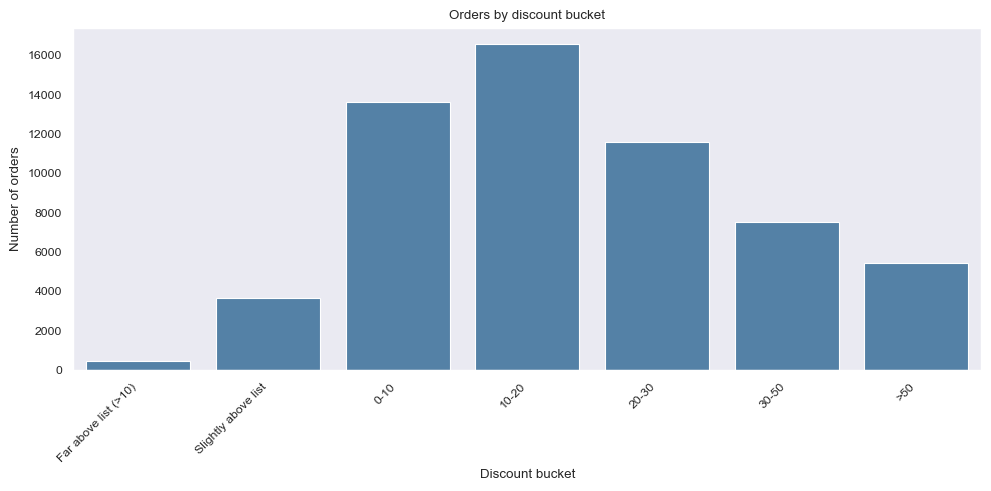

In [25]:
# discount["discount_bucket"] = pd.cut(discount["disc"], 
#     bins=[-1, 0, 10, 25, 50, 500], 
#     labels=["No discount", "0-10", "10-25", "25-50", ">50"])

# discount.groupby("discount_bucket")["id_order"].count()
discount["discount_bucket"] = pd.cut(discount["percent"], 
    bins=[-50, -10, 0, 10, 20, 30, 50, 500], 
    labels=["Far above list (>10)", "Slightly above list", "0-10", "10-20", "20-30", "30-50", ">50"])
analysis_disc = (
    discount.groupby("discount_bucket")["id_order"]
    .count()
    .reset_index(name="count")
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=analysis_disc,
    x="discount_bucket",
    y="count",
    color="steelblue"
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Discount bucket")
plt.ylabel("Number of orders")
plt.title("Orders by discount bucket")
plt.tight_layout()
plt.show()

## 3. Time analysis

In [26]:
monthly = discount.groupby(["year", "month"]).agg(
    avg_unit_price=("unit_price", "mean"),
    avg_list_price=("price", "mean"),
    total_sales=("id_order", "count")
).reset_index()

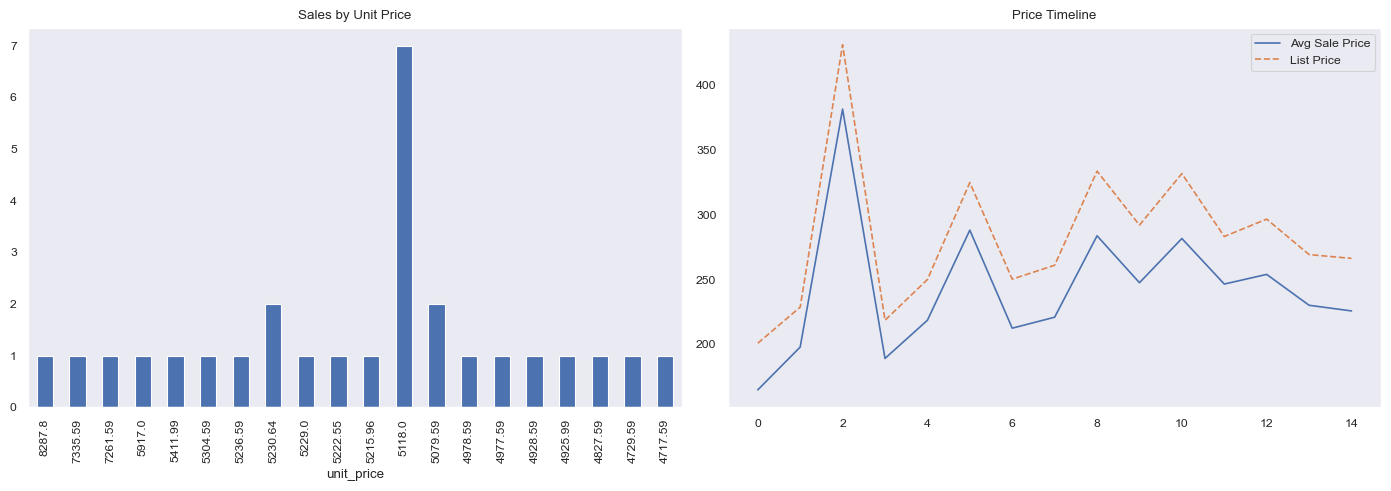

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

price_counts_df["sales_count"].head(20).plot(kind="bar", ax=axes[0], title="Sales by Unit Price")

monthly["avg_unit_price"].plot(ax=axes[1], label="Avg Sale Price")
monthly["avg_list_price"].plot(ax=axes[1], label="List Price", linestyle="--")
axes[1].set_title("Price Timeline")
axes[1].legend()

plt.tight_layout()
plt.show()

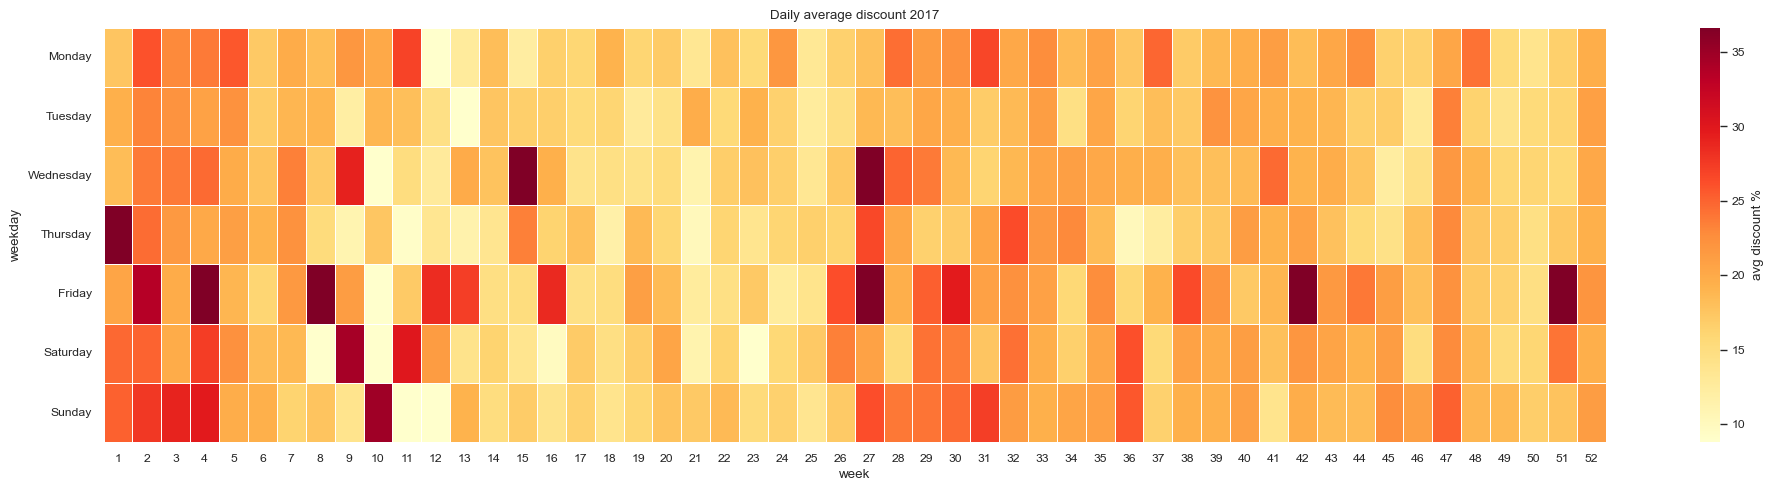

In [28]:
daily = discount.resample('D', on='date').mean(numeric_only=True)['percent']

df_heat = pd.DataFrame({'percent': daily})
df_heat['weekday'] = daily.index.day_name()
df_heat['week'] = daily.index.isocalendar().week.astype(int)
df_heat['year'] = daily.index.year

df_heat = df_heat[df_heat['year'] == 2017]  # ← filter here

pivot = df_heat.pivot_table(index='weekday', columns='week', values='percent', aggfunc='mean')
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(weekday_order)

plt.figure(figsize=(20, 5))
#sns.heatmap(pivot, cmap='tab20', linewidths=0.5, cbar_kws={'label': 'Orders'})
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.5, 
            robust=True, 
            #annot=True, fmt='.1f', # ignores outliers for color scaling
            cbar_kws={'label': 'avg discount %'})
plt.title('Daily average discount 2017')
plt.tight_layout()

# once you are ready with the figure, you can seve it in the proper folder
#plt.savefig('../MyEniacProject/Presentation/figs/HM_avg_disc_2017.svg')

plt.show()

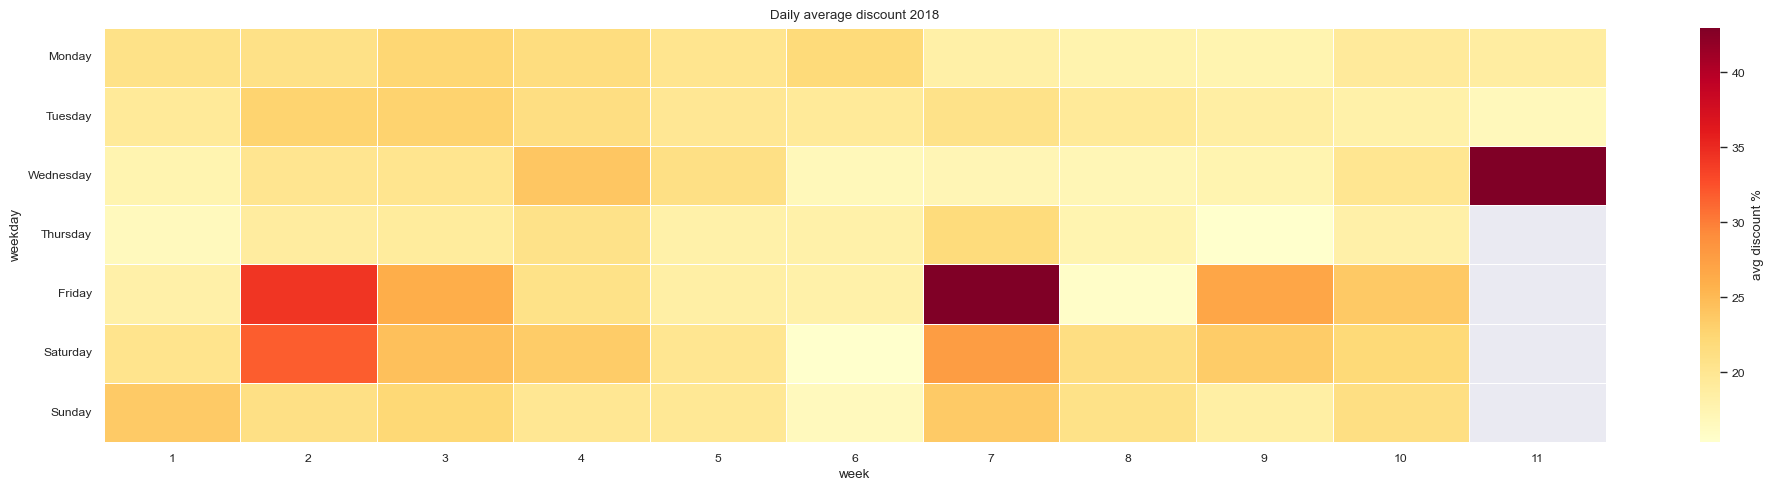

In [29]:
daily = discount.resample('D', on='date').mean(numeric_only=True)['percent']

df_heat = pd.DataFrame({'percent': daily})
df_heat['weekday'] = daily.index.day_name()
df_heat['week'] = daily.index.isocalendar().week.astype(int)
df_heat['year'] = daily.index.year

df_heat = df_heat[df_heat['year'] == 2018]  # ← filter here

pivot = df_heat.pivot_table(index='weekday', columns='week', values='percent', aggfunc='mean')
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(weekday_order)

plt.figure(figsize=(20, 5))
#sns.heatmap(pivot, cmap='tab20', linewidths=0.5, cbar_kws={'label': 'Orders'})
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.5, 
            robust=True, 
            #annot=True, fmt='.1f', # ignores outliers for color scaling
            cbar_kws={'label': 'avg discount %'})
plt.title('Daily average discount 2018')
plt.tight_layout()
# once you are ready with the figure, you can seve it in the proper folder
#plt.savefig('../MyEniacProject/Presentation/figs/HM_avg_disc_2018.svg')
plt.show()

Here are some lines of code i wrote but did not use

In [30]:
discount_df

,id_order,sku,unit_price,price,name,brand,state,type,category,type_cat,primary,secondary,disc,percent,year,month,day,weekday
date,,,,,,,,,,,,,,,,,,
2017-01-01 01:46:16,299545,OWC0100,47.49,60.99,OWC In-line Digital Temperature Sensor Kit HDD...,OWC,new,12755395,", desktop, kit",other,ssd,ssd,13.50,22.13,2017,1,1,Sunday
2017-01-01 01:50:34,299546,IOT0014,18.99,22.95,iOttie Easy View 2 Car Black Support,IOT,new,5720,", stand, support","cable, stand, support",support,support,3.96,17.25,2017,1,1,Sunday
2017-01-01 01:54:11,295347,APP0700,72.19,89.00,Apple 85W MagSafe 2 charger MacBook Pro screen...,APP,new,13005399,", laptop, charger",charger,macbook,charger,16.81,18.89,2017,1,1,Sunday
2017-01-01 02:07:42,299549,PAC0929,2565.99,3209.00,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB...",PAC,new,1282,", desktop","display, Apple MacBook Pro, Apple iMac",core,core,643.01,20.04,2017,1,1,Sunday
2017-01-01 02:20:14,299556,CRU0039-A,60.90,76.99,(Open) Crucial 240GB SSD 7mm BX200,CRU,new,1298,", storage","misc, open",mac,mac,16.09,20.90,2017,1,1,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-03-14 11:42:41,527035,APP0698,9.99,25.00,Apple Lightning Cable Connector to USB 1m Whit...,APP,new,1230,", cable",cable,cable,lightning,15.01,60.04,2018,3,14,Wednesday
2018-03-14 11:49:01,527070,APP0698,9.99,25.00,Apple Lightning Cable Connector to USB 1m Whit...,APP,new,1230,", cable",cable,cable,lightning,15.01,60.04,2018,3,14,Wednesday
2018-03-14 11:49:36,527074,APP0698,9.99,25.00,Apple Lightning Cable Connector to USB 1m Whit...,APP,new,1230,", cable",cable,cable,lightning,15.01,60.04,2018,3,14,Wednesday


In [31]:
discount.groupby('sku')['state'].value_counts()

sku        state      
8MO0001-A  second hand     1
8MO0003-A  second hand     1
8MO0007    new             7
8MO0008    new            10
8MO0009    new             5
                          ..
ZAG0040    new             1
ZAG0041    new             1
ZAG0042    new             1
ZEP0007    new             1
par0072    new             2
Name: count, Length: 5796, dtype: int64

In [32]:
test_df=(discount_df
    .query('price > 750')
    .groupby('sku')['state']
    .value_counts()
    .reset_index(name='count')
    .query('count > 5')
)
test_df

,sku,state,count
0,AP20028,second hand,6
2,AP20079,second hand,21
5,AP20084,second hand,16
14,AP20167,second hand,7
15,AP20169,second hand,6
...,...,...,...
913,WAC0216,new,6
916,WAC0219,new,8
918,WAC0228,new,30
920,WAC0234,new,8


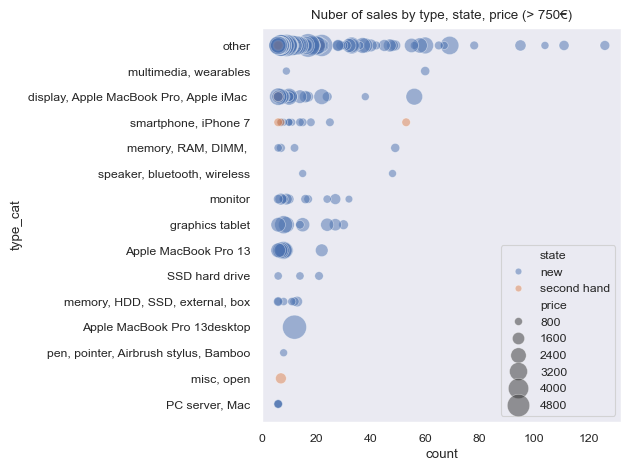

In [33]:
test_df = discount_df.query('price > 750').groupby(['sku', 'type', 'type_cat', 'price'])['state'].value_counts().sort_values(ascending=False).reset_index(name='count').query('count > 5')
fin=test_df.groupby('type').value_counts()
sns.scatterplot(data=test_df, y='type_cat', x='count', hue='state', size='price', sizes= (30, 300), alpha=0.5
                )
# Fix axis labels
plt.title("Nuber of sales by type, state, price (> 750€)")
ax.set_xlabel("Count")
ax.set_ylabel("Category")

# Set axis limits on the joint axes
ax.set_xlim(0, 120)
#ax.set_ylim(0, 3000)
plt.tight_layout()

# once you are ready with the figure, you can seve it in the proper folder
#plt.savefig('../MyEniacProject/Presentation/figs/dist_sale_type_state_price.svg')

58867 items sold
	13137 items are Apple
	12202 are new

7482 items cost > 500€
	4412 items are Apple
	3941 are new

4552 items cost > 1000€
	2486 items are Apple
	2329 are new

1663 items cost > 2000€
	1041 items are Apple
	1001 are new
165 	tems cost > 4000€
	29 items are Apple
	29 are new
discount_df.brand.isin(['APP', 'AP2']).value_counts()
brand False 45730 True

In [65]:
discount_df.query('price > 4000').brand.isin(['APP','AP2']).value_counts()

brand
False    136
True      29
Name: count, dtype: int64

In [1]:
# import pandas as pd
# import numpy as np

# # Define price bins: 0, 250, 500, ..., 5000
# bins = list(range(0, 5250, 250))

# # Cut prices into bins
# discount_df['price_bin'] = pd.cut(discount_df['price'], bins=bins, right=False)

# # Boolean masks
# is_app_or_ap2 = discount_df['brand'].isin(['APP', 'AP2'])
# is_app_only   = discount_df['brand'] == 'APP'

# # Group and aggregate
# result_df = (
#     discount_df
#     .groupby('price_bin', observed=False)
#     .agg(
#         total_count      = ('brand', 'count'),
#         app_and_ap2_true = ('brand', lambda x: is_app_or_ap2.loc[x.index].sum()),
#         app_only_true    = ('brand', lambda x: is_app_only.loc[x.index].sum()),
#     )
#     .reset_index()
# )
# result_df
# sns.histplot(data=result_df,  y='total_count')